# 🦗 Cricket Perception — Step 4: Behavior Analysis

**Pipeline:** `Raw Audio → Features → UMAP+HDBSCAN → **Behavior Alerts** ← (คุณอยู่ที่นี่)**

Notebook นี้รับ output จาก notebook 03 (cluster labels + embeddings) แล้วแปลงเป็น **farm-actionable alerts**:

| Alert | สัญญาณ | Threshold |
|-------|--------|----------|
| 🍽️ Hunger | Aggressive Song cluster fraction > 35% | configurable |
| 🚨 Mortality | RMS < 40% baseline **หรือ** ACI < 50% baseline | configurable |
| 🌡️ Temperature | Dolbear's Law Q10 correction | auto |

---

In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from pathlib import Path
from datetime import datetime, timedelta

from cricket_perception.behavior import (
    BehaviorMonitor,
    BehaviorResult,
    hunger_alert,
    mortality_alert,
    temperature_from_chirps,
    chirp_rate_correction_factor,
)

# ── Dark theme ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f0f1a',
    'axes.facecolor':    '#0f0f1a',
    'axes.edgecolor':    '#333355',
    'axes.labelcolor':   '#ccccee',
    'text.color':        '#ccccee',
    'xtick.color':       '#aaaacc',
    'ytick.color':       '#aaaacc',
    'grid.color':        '#1e1e3a',
    'grid.linestyle':    '--',
    'legend.facecolor':  '#1a1a2e',
    'legend.edgecolor':  '#333355',
    'font.family':       'DejaVu Sans',
    'font.size':         11,
})

RESULTS = Path('../results')
RESULTS.mkdir(exist_ok=True)
print('Imports OK')

✅ Imports OK


## 1️⃣ โหลดข้อมูลจาก Notebook 03

In [3]:
# โหลด cluster results
df = pd.read_csv(RESULTS / 'segments_with_clusters.csv')
pipe = pickle.load(open(RESULTS / 'cluster_pipeline.pkl', 'rb'))

# โหลด feature matrix
X = np.load('../features_cache/features_X.npy')
meta = pd.read_csv('../features_cache/features_meta.csv')

# Feature column indices (ตาม README: MFCC 26, Spectral 8, Chroma+ZCR 14, RMS 4, ACI 1)
RMS_COLS = slice(48, 52)   # 4 RMS stats
ACI_COL  = 52              # ACI index

embedding = pipe.embedding_
labels    = pipe.labels_

unique_clusters = sorted(df['cluster'].unique())
n_clusters = len([c for c in unique_clusters if c >= 0])

print(f'Segments    : {len(df):,}')
print(f'Clusters    : {n_clusters} (+ noise cluster -1)')
print(f'Noise pts   : {(labels == -1).sum()} ({(labels==-1).mean():.1%})')
print(f'Species     : {df["species"].nunique()}')
print(f'Feature dim : {X.shape[1]}')
df.head(3)

Segments    : 759
Clusters    : 37 (+ noise cluster -1)
Noise pts   : 96 (12.6%)
Species     : 9
Feature dim : 53


,file,species,segment,start_s,cluster
0,Chorthippusbiguttulus/Chorthippusbiguttulus_CH...,Chorthippusbiguttulus,0,0.0,28
1,Chorthippusbiguttulus/Chorthippusbiguttulus_CH...,Chorthippusbiguttulus,1,2.5,28
2,Chorthippusbiguttulus/Chorthippusbiguttulus_CH...,Chorthippusbiguttulus,2,5.0,29


## 2️⃣ Cluster Characterisation

วิเคราะห์แต่ละ cluster จาก:
- **Species purity** — cluster ไหนมี species เดียวเด่น → อาจเป็น species-specific call type
- **RMS Energy** — cluster ที่ดังมาก = Aggressive/Calling; เงียบ = กิจกรรมน้อย  
- **ACI** — ค่าสูง = เสียงซับซ้อน (biotic richness)

> ⚠️ **Dataset นี้คือ InsectSet32 (field recordings หลาย species)**  
> ใน farm จริงจะมีแค่ Gryllus bimaculatus — cluster จะสะท้อน *song type* ไม่ใช่ species

In [4]:
# ── สร้าง cluster summary DataFrame ──────────────────────────────────────────
records = []
for cid in unique_clusters:
    mask = df['cluster'] == cid
    idxs = df.index[mask].tolist()
    
    if len(idxs) == 0:
        continue
    
    feat_subset = X[idxs]
    rms_mean    = float(feat_subset[:, RMS_COLS].mean())
    aci_mean    = float(feat_subset[:, ACI_COL].mean())
    
    # dominant species
    species_counts = df[mask]['species'].value_counts()
    dom_species    = species_counts.index[0]
    dom_purity     = species_counts.iloc[0] / species_counts.sum()
    
    records.append({
        'cluster':      cid,
        'count':        mask.sum(),
        'fraction':     mask.sum() / len(df),
        'rms_mean':     rms_mean,
        'aci_mean':     aci_mean,
        'dom_species':  dom_species,
        'dom_purity':   dom_purity,
        'is_noise':     cid == -1,
    })

cluster_summary = pd.DataFrame(records).sort_values('cluster')
cluster_summary_valid = cluster_summary[cluster_summary['cluster'] >= 0].copy()

print(f'Cluster summary ({len(cluster_summary_valid)} clusters):')
cluster_summary_valid[['cluster','count','fraction','rms_mean','aci_mean','dom_species','dom_purity']].to_string(index=False, float_format='{:.4f}'.format)


Cluster summary (37 clusters):


' cluster  count  fraction  rms_mean  aci_mean                 dom_species  dom_purity\n       0     11    0.0145    0.0496  508.8379          Oecanthuspellucens      1.0000\n       1     19    0.0250    0.0191  537.2035          Oecanthuspellucens      1.0000\n       2     12    0.0158    0.0456  588.3188           Grylluscampestris      1.0000\n       3     13    0.0171    0.0220  501.6967          Oecanthuspellucens      1.0000\n       4     11    0.0145    0.0184  505.8481          Oecanthuspellucens      1.0000\n       5     21    0.0277    0.0193  510.1747          Oecanthuspellucens      1.0000\n       6     11    0.0145    0.0065  496.0565          Nemobiussylvestris      1.0000\n       7     16    0.0211    0.0057  517.3451           Grylluscampestris      0.6250\n       8     21    0.0277    0.0009  513.1387          Nemobiussylvestris      1.0000\n       9     14    0.0184    0.0808  682.9535           Grylluscampestris      1.0000\n      10     20    0.0264    0.0303  528.2

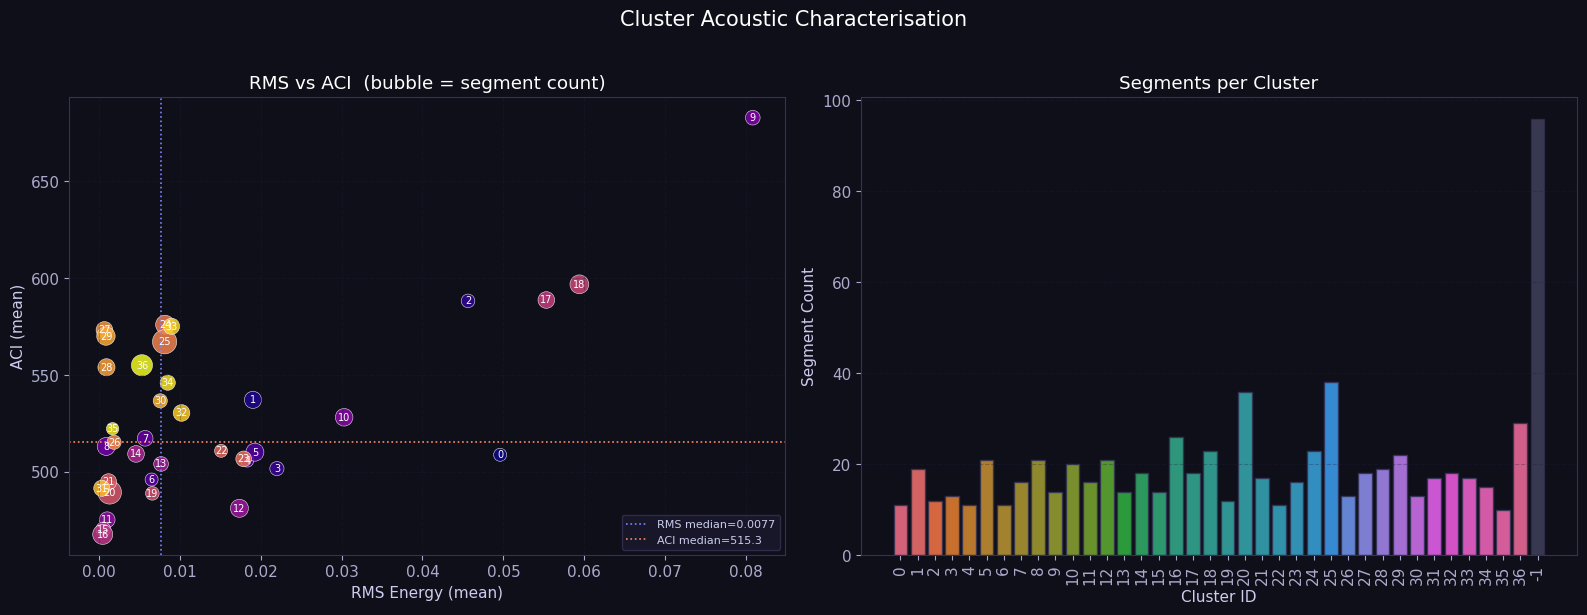

Saved → results/04_cluster_characterisation.png


In [5]:
# ── Plot: RMS vs ACI per cluster (bubble = cluster size) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cluster Acoustic Characterisation', fontsize=15, color='white', y=1.02)

cv = cluster_summary_valid
palette = sns.color_palette('husl', n_colors=len(cv))

# Panel 1: RMS vs ACI scatter
ax = axes[0]
sc = ax.scatter(
    cv['rms_mean'], cv['aci_mean'],
    s=cv['count'] * 8,
    c=cv['cluster'], cmap='plasma',
    alpha=0.85, edgecolors='white', linewidths=0.4
)
for _, row in cv.iterrows():
    ax.annotate(str(int(row['cluster'])),
                (row['rms_mean'], row['aci_mean']),
                fontsize=7, color='white', ha='center', va='center')
ax.set_xlabel('RMS Energy (mean)')
ax.set_ylabel('ACI (mean)')
ax.set_title('RMS vs ACI  (bubble = segment count)', color='white')
ax.grid(True, alpha=0.3)

# Reference lines (median)
ax.axvline(cv['rms_mean'].median(), color='#7c85ff', ls=':', lw=1.2, label=f'RMS median={cv["rms_mean"].median():.4f}')
ax.axhline(cv['aci_mean'].median(), color='#ff8a65', ls=':', lw=1.2, label=f'ACI median={cv["aci_mean"].median():.1f}')
ax.legend(fontsize=8)

# Panel 2: Cluster size bar chart
ax2 = axes[1]
colors = [palette[i] for i in range(len(cv))]
bars = ax2.bar(cv['cluster'].astype(str), cv['count'], color=colors, alpha=0.85, edgecolor='#333355')
ax2.set_xlabel('Cluster ID')
ax2.set_ylabel('Segment Count')
ax2.set_title('Segments per Cluster', color='white')
ax2.tick_params(axis='x', rotation=90)
ax2.grid(True, axis='y', alpha=0.3)

# Label noise bar differently
noise_count = (labels == -1).sum()
ax2.bar(['-1'], [noise_count], color='#555577', alpha=0.6, edgecolor='#333355', label='Noise')

plt.tight_layout()
fig.savefig(RESULTS / '04_cluster_characterisation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Saved → results/04_cluster_characterisation.png')

## 3️⃣ Auto-Label Clusters → Song Types

ใช้ **rule-based heuristics** จาก acoustic properties:

| Song Type | RMS | ACI | ความหมาย |
|-----------|-----|-----|----------|
| 🔴 Aggressive Song | > Q75 | any | เสียงต่อสู้แย่งอาหาร/อาณาเขต |
| 🟢 Calling Song | Q25-Q75 | > median | เสียงผสมพันธุ์ปกติ |
| 🔵 Courtship/Low | < Q25 | > median | เสียงเบา/เกี้ยวพาราสี |
| ⚪ Quiet/Background | any | < median | กิจกรรมน้อย |

> **หมายเหตุ**: สำหรับ dataset จริง (InsectSet32) มีหลาย species — label เหล่านี้ใช้เป็น *proxy* สำหรับทดสอบ BehaviorMonitor

In [6]:
# ── Auto-label clusters based on acoustic statistics ─────────────────────────
rms_q25 = cv['rms_mean'].quantile(0.25)
rms_q75 = cv['rms_mean'].quantile(0.75)
aci_med  = cv['aci_mean'].median()

SONG_TYPE_COLORS = {
    'Aggressive Song': '#ff5252',
    'Calling Song':    '#69f0ae',
    'Courtship/Low':   '#40c4ff',
    'Quiet/Background':'#aaaacc',
}

def auto_label(row):
    rms = row['rms_mean']
    aci = row['aci_mean']
    if rms >= rms_q75:
        return 'Aggressive Song'
    elif rms >= rms_q25 and aci >= aci_med:
        return 'Calling Song'
    elif rms < rms_q25 and aci >= aci_med:
        return 'Courtship/Low'
    else:
        return 'Quiet/Background'

cluster_summary_valid['song_type'] = cluster_summary_valid.apply(auto_label, axis=1)

# Build lookup dicts for BehaviorMonitor
aggressive_ids = cluster_summary_valid[cluster_summary_valid['song_type'] == 'Aggressive Song']['cluster'].tolist()
calling_ids    = cluster_summary_valid[cluster_summary_valid['song_type'] == 'Calling Song']['cluster'].tolist()
courtship_ids  = cluster_summary_valid[cluster_summary_valid['song_type'] == 'Courtship/Low']['cluster'].tolist()
quiet_ids      = cluster_summary_valid[cluster_summary_valid['song_type'] == 'Quiet/Background']['cluster'].tolist()

print('🎵 Song Type Distribution:')
print(cluster_summary_valid['song_type'].value_counts().to_string())
print()
print(f'Aggressive clusters: {aggressive_ids}')
print(f'Calling clusters   : {calling_ids}')
print(f'Courtship clusters : {courtship_ids}')
print(f'Quiet clusters     : {quiet_ids}')

🎵 Song Type Distribution:
song_type
Quiet/Background    14
Aggressive Song     10
Calling Song        10
Courtship/Low        3

Aggressive clusters: [0, 1, 2, 3, 4, 5, 9, 10, 17, 18]
Calling clusters   : [7, 24, 25, 26, 30, 32, 33, 34, 35, 36]
Courtship clusters : [27, 28, 29]
Quiet clusters     : [6, 8, 11, 12, 13, 14, 15, 16, 19, 20, 21, 22, 23, 31]


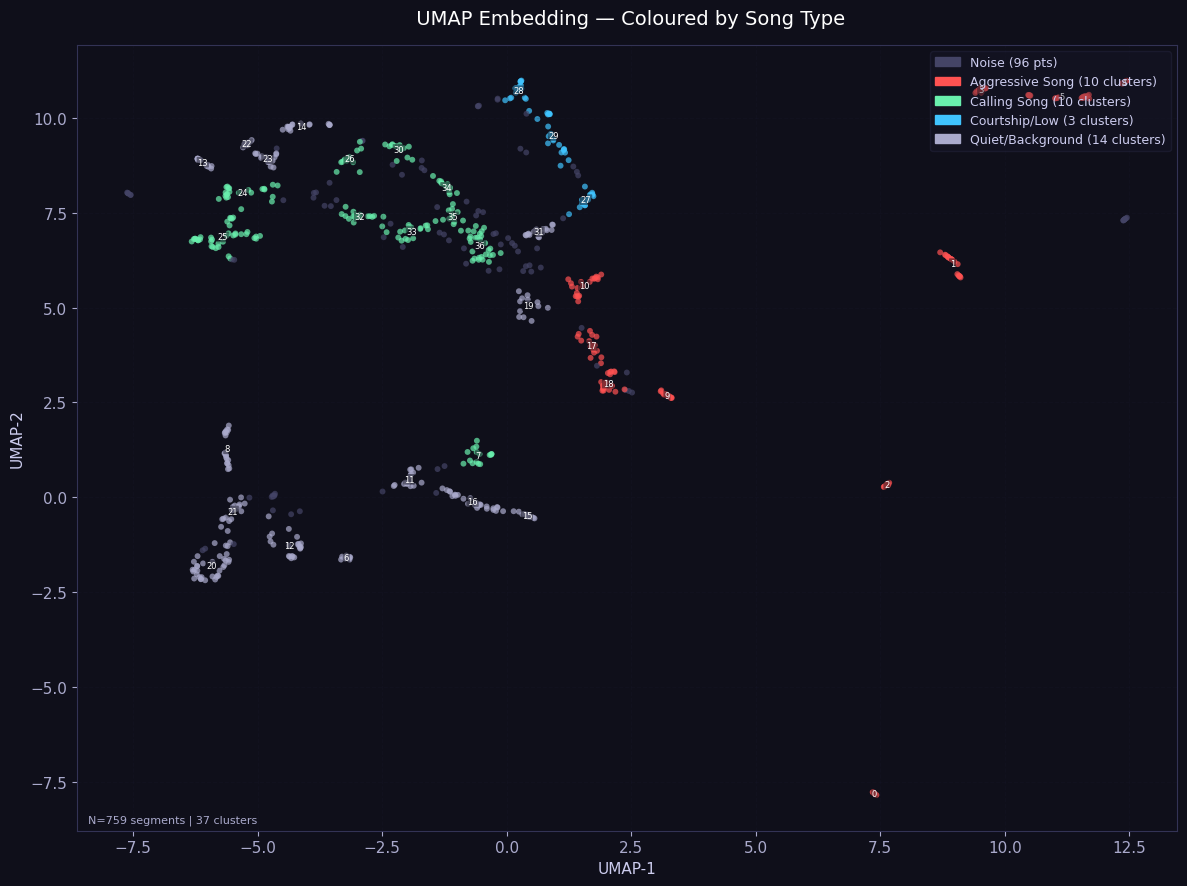

Saved → results/04_umap_song_types.png


In [19]:
# ── UMAP scatter coloured by Song Type ───────────────────────────────────────
# Build color array for all 759 points
cluster_to_type = dict(zip(cluster_summary_valid['cluster'], cluster_summary_valid['song_type']))

point_colors = []
for lbl in labels:
    if lbl == -1:
        point_colors.append('#444466')  # noise = dark grey
    else:
        stype = cluster_to_type.get(lbl, 'Quiet/Background')
        point_colors.append(SONG_TYPE_COLORS[stype])

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=point_colors, alpha=0.7, s=18, edgecolors='none'
)

# Legend
legend_items = [
    mpatches.Patch(color='#444466',              label=f'Noise ({(labels==-1).sum()} pts)'),
    mpatches.Patch(color='#ff5252',              label=f'Aggressive Song ({len(aggressive_ids)} clusters)'),
    mpatches.Patch(color='#69f0ae',              label=f'Calling Song ({len(calling_ids)} clusters)'),
    mpatches.Patch(color='#40c4ff',              label=f'Courtship/Low ({len(courtship_ids)} clusters)'),
    mpatches.Patch(color='#aaaacc',              label=f'Quiet/Background ({len(quiet_ids)} clusters)'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=9, framealpha=0.3)
ax.set_title(' UMAP Embedding — Coloured by Song Type', fontsize=14, color='white', pad=15)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

# Annotate cluster centroids
for cid, stype in cluster_to_type.items():
    mask = labels == cid
    if mask.sum() == 0: continue
    cx, cy = embedding[mask, 0].mean(), embedding[mask, 1].mean()
    ax.text(cx, cy, str(cid), fontsize=6, color='white', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.1', facecolor='#0f0f1a', alpha=0.5, edgecolor='none'))

ax.grid(True, alpha=0.15)
ax.text(0.01, 0.01, f'N={len(labels)} segments | {n_clusters} clusters',
        transform=ax.transAxes, fontsize=8, color='#aaaacc')

plt.tight_layout()
fig.savefig(RESULTS / '04_umap_song_types.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Saved → results/04_umap_song_types.png')

## 4️⃣ Baseline Calibration

**Baseline** = ค่า RMS และ ACI ของอาณานิคมที่สุขภาพดี  
ใช้ **percentile ที่ 60** ของ non-noise segments เป็น baseline (robust ต่อ outlier)

Baseline calibration (60th percentile of non-noise segments):
   RMS baseline : 0.00848
   ACI baseline : 531.53

RMS range    : 0.00001 – 0.10552
ACI range    : 446.2 – 804.5


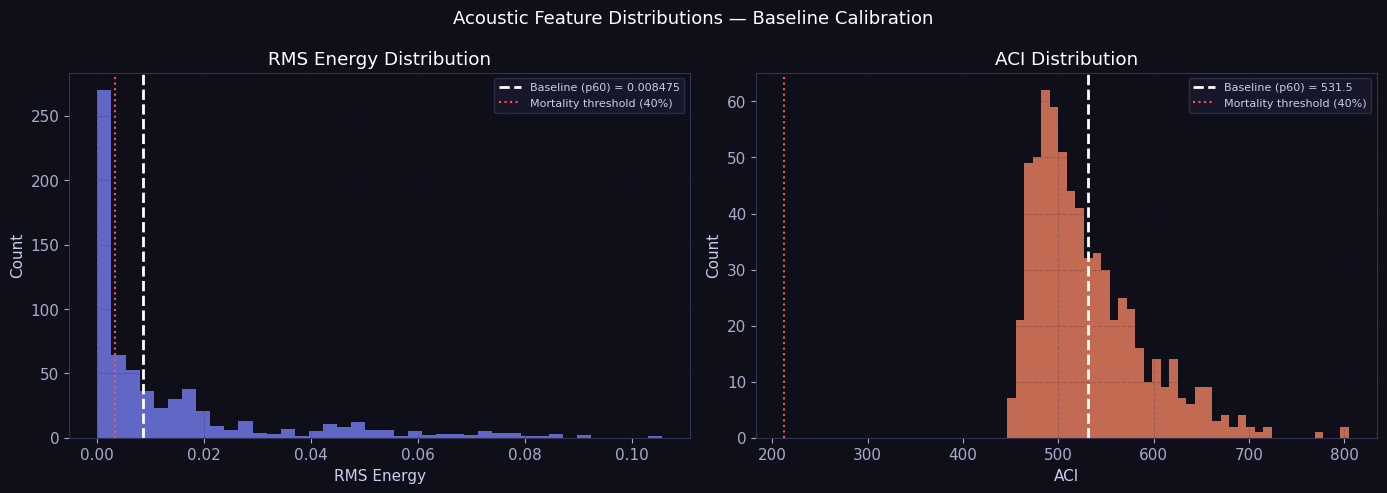

Saved → results/04_baseline_calibration.png


In [8]:
# ── Calibrate baseline from non-noise segments ────────────────────────────────
non_noise_mask  = labels != -1
X_valid         = X[non_noise_mask]

# RMS baseline: mean of the 4 RMS stat columns, then 60th percentile
rms_per_segment = X_valid[:, RMS_COLS].mean(axis=1)
aci_per_segment = X_valid[:, ACI_COL]

RMS_BASELINE = float(np.percentile(rms_per_segment, 60))
ACI_BASELINE = float(np.percentile(aci_per_segment, 60))

print(f'Baseline calibration (60th percentile of non-noise segments):')
print(f'   RMS baseline : {RMS_BASELINE:.5f}')
print(f'   ACI baseline : {ACI_BASELINE:.2f}')
print()
print(f'RMS range    : {rms_per_segment.min():.5f} – {rms_per_segment.max():.5f}')
print(f'ACI range    : {aci_per_segment.min():.1f} – {aci_per_segment.max():.1f}')

# Visualise distributions + baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Acoustic Feature Distributions — Baseline Calibration', fontsize=13, color='white')

for ax, data, label, baseline, color in [
    (axes[0], rms_per_segment, 'RMS Energy', RMS_BASELINE, '#7c85ff'),
    (axes[1], aci_per_segment, 'ACI',        ACI_BASELINE, '#ff8a65'),
]:
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(baseline, color='white', ls='--', lw=2, label=f'Baseline (p60) = {baseline:.4g}')
    ax.axvline(baseline * 0.4, color='#ff5252', ls=':', lw=1.5, label=f'Mortality threshold (40%)')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Distribution', color='white')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig(RESULTS / '04_baseline_calibration.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Saved → results/04_baseline_calibration.png')

## 5️⃣ Configure BehaviorMonitor

In [9]:
# ── Initialise BehaviorMonitor ─────────────────────────────────────────────────
monitor = BehaviorMonitor(
    rms_baseline          = RMS_BASELINE,
    aci_baseline          = ACI_BASELINE,
    reference_temp_c      = 28.0,          # calibration temperature
    aggressive_cluster_ids= aggressive_ids,
    calling_cluster_ids   = calling_ids,
    aggressive_threshold  = 0.35,          # >35% Aggressive → hunger alert
    rms_low_threshold     = 0.40,          # RMS < 40% baseline → mortality
    aci_low_threshold     = 0.50,          # ACI < 50% baseline → mortality
)

print('BehaviorMonitor configured')
print(f'   RMS baseline          : {monitor.rms_baseline:.5f}')
print(f'   ACI baseline          : {monitor.aci_baseline:.2f}')
print(f'   Reference temp        : {monitor.reference_temp_c}°C')
print(f'   Aggressive cluster IDs: {monitor.aggressive_cluster_ids}')
print(f'   Calling cluster IDs   : {monitor.calling_cluster_ids}')
print(f'   Aggressive threshold  : {monitor.aggressive_threshold:.0%}')
print(f'   RMS low threshold     : {monitor.rms_low_threshold:.0%} of baseline')
print(f'   ACI low threshold     : {monitor.aci_low_threshold:.0%} of baseline')

BehaviorMonitor configured
   RMS baseline          : 0.00848
   ACI baseline          : 531.53
   Reference temp        : 28.0°C
   Aggressive cluster IDs: [0, 1, 2, 3, 4, 5, 9, 10, 17, 18]
   Calling cluster IDs   : [7, 24, 25, 26, 30, 32, 33, 34, 35, 36]
   Aggressive threshold  : 35%
   RMS low threshold     : 40% of baseline
   ACI low threshold     : 50% of baseline


## 6️⃣ Simulate Time-Series Monitoring

จำลอง **24 ชั่วโมง** ของการ monitor โดยแบ่ง segments เป็น time windows (30 นาที/window)  
แต่ละ window จะมี:
- **Cluster fractions** — สัดส่วนของแต่ละ song type
- **RMS + ACI** — ค่าเฉลี่ยของ window นั้น
- **Temperature** — จำลองการขึ้น-ลงของอุณหภูมิรายวัน

In [11]:
# ── Simulate 24-hour time series ──────────────────────────────────────────────
np.random.seed(42)

# Parameters
N_WINDOWS   = 48          # 48 x 30-min = 24h
WINDOW_SIZE = max(10, len(df) // N_WINDOWS)   # segments per window

# Circadian temperature curve: 24-32°C peak at 14:00
hours = np.linspace(0, 24, N_WINDOWS)
temp_curve = 28.0 + 4.0 * np.sin(np.pi * (hours - 6) / 12)

# Inject stress events for demo:
#   Window 20-27 (10:00-13:30): hunger spike (add more aggressive-like segments)
#   Window 38-42 (19:00-21:00): mortality event (low RMS + ACI)
HUNGER_WINDOWS    = set(range(20, 28))
MORTALITY_WINDOWS = set(range(38, 43))

results = []
base_time = datetime(2026, 5, 28, 0, 0, 0)

all_cluster_ids = [c for c in unique_clusters if c >= 0]

for w in range(N_WINDOWS):
    ts = base_time + timedelta(minutes=30 * w)
    temp_c = float(temp_curve[w])
    
    # Generate cluster fractions for this window
    # Normal: sample from observed distribution
    raw_fracs = {cid: float(cluster_summary_valid[cluster_summary_valid['cluster']==cid]['fraction'].values[0])
                 for cid in all_cluster_ids}
    
    if w in HUNGER_WINDOWS:
        # Boost aggressive clusters
        for cid in aggressive_ids:
            raw_fracs[cid] = raw_fracs.get(cid, 0.01) * 4.5
        noise_frac = 0.05
        rms_val = RMS_BASELINE * np.random.uniform(0.85, 1.15)
        aci_val = ACI_BASELINE * np.random.uniform(0.90, 1.10)
    elif w in MORTALITY_WINDOWS:
        # Drop RMS and ACI drastically
        noise_frac = 0.3
        rms_val = RMS_BASELINE * np.random.uniform(0.15, 0.35)  # way below baseline
        aci_val = ACI_BASELINE * np.random.uniform(0.25, 0.45)
    else:
        noise_frac = 0.1
        rms_val = RMS_BASELINE * np.random.uniform(0.7, 1.3)
        aci_val = ACI_BASELINE * np.random.uniform(0.75, 1.25)
    
    # Normalise fractions (exclude noise)
    total_frac = sum(raw_fracs.values())
    scale = (1.0 - noise_frac) / (total_frac + 1e-8)
    cluster_fractions = {cid: v * scale for cid, v in raw_fracs.items()}
    cluster_fractions[-1] = noise_frac
    
    result = monitor.analyze(
        rms=rms_val,
        aci=aci_val,
        cluster_fractions=cluster_fractions,
        temperature_c=temp_c,
        timestamp=ts,
    )
    
    agg_frac = sum(cluster_fractions.get(c, 0) for c in aggressive_ids)
    
    results.append({
        'timestamp':       ts,
        'hour':            ts.hour + ts.minute / 60,
        'temperature_c':   temp_c,
        'rms':             rms_val,
        'aci':             aci_val,
        'rms_ratio':       result.mortality['rms_ratio'],
        'aci_ratio':       result.mortality['aci_ratio'],
        'aggressive_frac': agg_frac,
        'hungry':          result.hunger['hungry'],
        'mortality_risk':  result.mortality['mortality_risk'],
        'is_critical':     result.is_critical,
        'alerts':          result.alerts,
    })

ts_df = pd.DataFrame(results)

n_hungry    = ts_df['hungry'].sum()
n_mortality = ts_df['mortality_risk'].sum()
print(f'  Simulated {N_WINDOWS} windows (30-min each = 24h)')
print(f'  Hunger alerts    : {n_hungry}/{N_WINDOWS} windows ({n_hungry/N_WINDOWS:.0%})')
print(f' Mortality alerts : {n_mortality}/{N_WINDOWS} windows ({n_mortality/N_WINDOWS:.0%})')
ts_df[['timestamp','temperature_c','rms_ratio','aci_ratio','aggressive_frac','hungry','mortality_risk']].head(8)

🚨 Critical alerts at 2026-05-28T10:00:00: ['⚠️  HUNGER ALERT: Aggressive fraction 56.3% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T10:30:00: ['⚠️  HUNGER ALERT: Aggressive fraction 56.3% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T11:00:00: ['⚠️  HUNGER ALERT: Aggressive fraction 56.3% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T11:30:00: ['⚠️  HUNGER ALERT: Aggressive fraction 56.3% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T12:00:00: ['⚠️  HUNGER ALERT: Aggressive fraction 56.3% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T12:30:00: ['⚠️  HUNGER ALERT: Aggressive fraction 56.3% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T13:00:00: ['⚠️  HUNGER ALERT: Aggressive fraction 56.3% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T13:30:00: ['⚠️  HUNGER ALERT: Aggressive fraction 56.3% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T19:00:00: ['🚨 MORTALITY RISK: RMS ratio=0.34, ACI ratio=0.29']
🚨 Critical alerts at 2026-05-28T19:30:00: ['🚨 MORTALITY RISK: RMS ratio=0.25, ACI ratio=0.31']
🚨 Critical alerts at 2026-

  Simulated 48 windows (30-min each = 24h)
  Hunger alerts    : 8/48 windows (17%)
 Mortality alerts : 5/48 windows (10%)


,timestamp,temperature_c,rms_ratio,aci_ratio,aggressive_frac,hungry,mortality_risk
0,2026-05-28 00:00:00,24.000000,1.2202,1.6169,0.219909,False,False
1,2026-05-28 00:30:00,24.035690,1.4995,1.3812,0.219909,False,False
2,2026-05-28 01:00:00,24.142123,1.0369,1.0818,0.219909,False,False
3,2026-05-28 01:30:00,24.317400,0.9485,1.5271,0.219909,False,False
4,2026-05-28 02:00:00,24.558394,1.3464,1.4015,0.219909,False,False
5,2026-05-28 02:30:00,24.860802,0.8855,1.5351,0.219909,False,False
6,2026-05-28 03:00:00,25.219230,1.4544,1.0382,0.219909,False,False
7,2026-05-28 03:30:00,25.627281,0.9537,0.9922,0.219909,False,False


## 7️⃣ Alert Timeline Dashboard

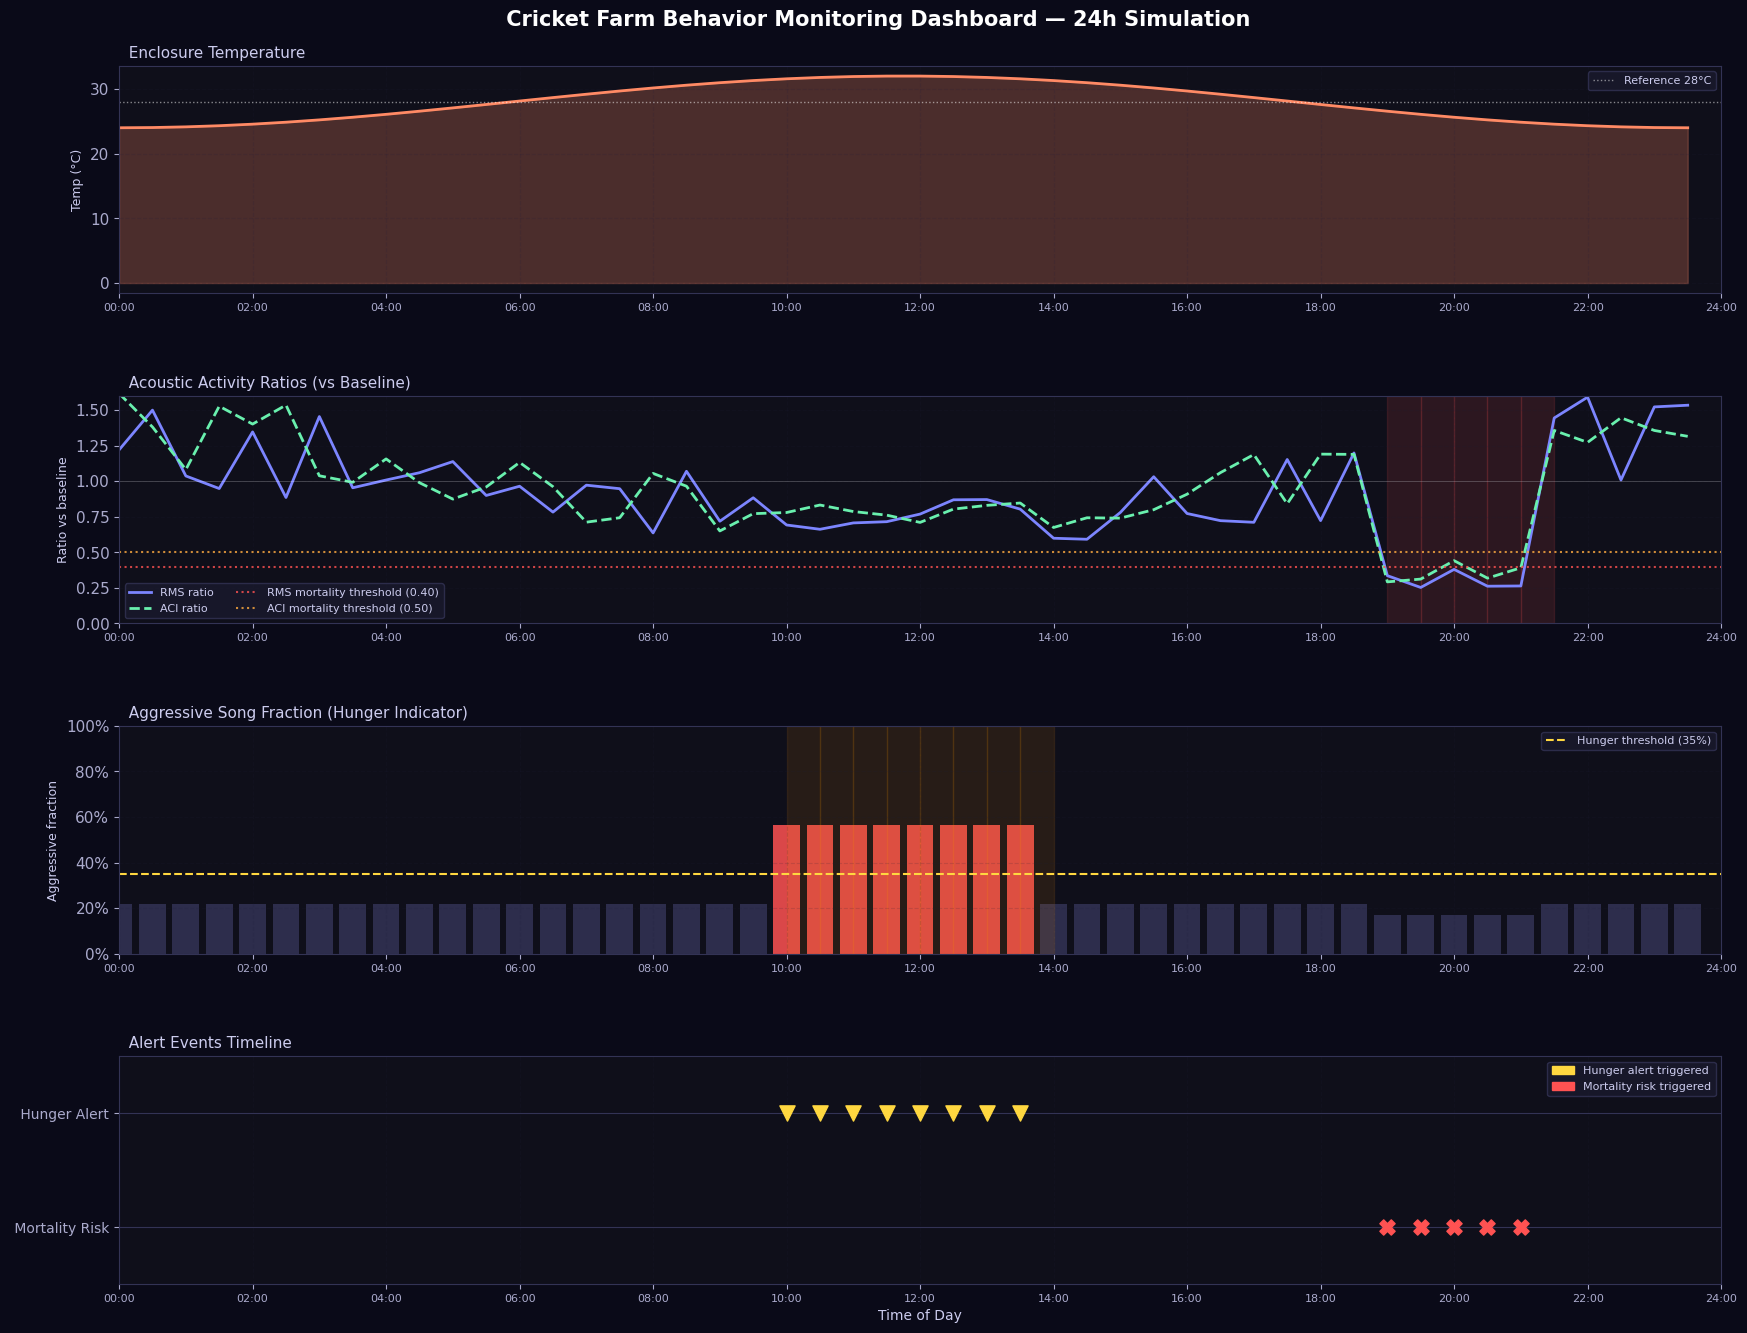

 Saved → results/04_behavior_dashboard.png


In [18]:
# ── Main Dashboard Plot ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0a0a18')

gs = gridspec.GridSpec(4, 1, figure=fig, hspace=0.45,
                       top=0.93, bottom=0.06, left=0.08, right=0.97)

hours_arr     = ts_df['hour'].values
xtick_hours   = range(0, 25, 2)
xlabels       = [f'{h:02d}:00' for h in xtick_hours]

def style_ax(ax, title):
    ax.set_facecolor('#0f0f1a')
    ax.set_xlim(0, 24)
    ax.set_xticks(list(xtick_hours))
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.grid(True, alpha=0.15)
    ax.set_title(title, color='#ccccee', fontsize=11, loc='left', pad=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

# ── Panel 1: Temperature ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.fill_between(hours_arr, ts_df['temperature_c'], alpha=0.25, color='#ff8a65')
ax1.plot(hours_arr, ts_df['temperature_c'], color='#ff8a65', lw=2)
ax1.axhline(28, color='white', ls=':', lw=1, alpha=0.5, label='Reference 28°C')
ax1.set_ylabel('Temp (°C)', fontsize=9)
ax1.legend(fontsize=8, loc='upper right')
style_ax(ax1, '  Enclosure Temperature')

# ── Panel 2: RMS + ACI ratios ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(hours_arr, ts_df['rms_ratio'], color='#7c85ff', lw=2, label='RMS ratio')
ax2.plot(hours_arr, ts_df['aci_ratio'], color='#69f0ae', lw=2, ls='--', label='ACI ratio')
ax2.axhline(0.4,  color='#ff5252', ls=':', lw=1.5, alpha=0.8, label='RMS mortality threshold (0.40)')
ax2.axhline(0.5,  color='#ffab40', ls=':', lw=1.5, alpha=0.8, label='ACI mortality threshold (0.50)')
ax2.axhline(1.0,  color='white',   ls='-', lw=0.5, alpha=0.3)
ax2.set_ylabel('Ratio vs baseline', fontsize=9)
ax2.set_ylim(0, 1.6)
ax2.legend(fontsize=8, ncol=2)

# Shade mortality windows
for w in MORTALITY_WINDOWS:
    t0 = w * 0.5
    ax2.axvspan(t0, t0 + 0.5, color='#ff5252', alpha=0.12)

style_ax(ax2, '  Acoustic Activity Ratios (vs Baseline)')

# ── Panel 3: Aggressive Fraction ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
bar_colors = ['#ff5252' if h else '#333355' for h in ts_df['hungry']]
ax3.bar(hours_arr, ts_df['aggressive_frac'], width=0.4, color=bar_colors, alpha=0.85, edgecolor='none')
ax3.axhline(0.35, color='#ffd740', ls='--', lw=1.5, label='Hunger threshold (35%)')
ax3.set_ylabel('Aggressive fraction', fontsize=9)
ax3.set_ylim(0, 1)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax3.legend(fontsize=8)

# Shade hunger windows
for w in HUNGER_WINDOWS:
    t0 = w * 0.5
    ax3.axvspan(t0, t0 + 0.5, color='#ff9800', alpha=0.10)

style_ax(ax3, '  Aggressive Song Fraction (Hunger Indicator)')

# ── Panel 4: Alert timeline ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3])

for w_idx, row in ts_df.iterrows():
    h = row['hour']
    if row['hungry']:
        ax4.scatter(h, 1, color='#ffd740', s=120, marker='v', zorder=5)
    if row['mortality_risk']:
        ax4.scatter(h, 0, color='#ff5252', s=120, marker='X', zorder=5)

ax4.set_yticks([0, 1])
ax4.set_yticklabels([' Mortality Risk', ' Hunger Alert'], fontsize=10)
ax4.set_ylim(-0.5, 1.5)
ax4.axhline(0, color='#333355', lw=0.8)
ax4.axhline(1, color='#333355', lw=0.8)
ax4.set_xlabel('Time of Day', fontsize=10)
style_ax(ax4, '  Alert Events Timeline')

# Add legend for markers
h_patch  = mpatches.Patch(color='#ffd740', label='Hunger alert triggered')
m_patch  = mpatches.Patch(color='#ff5252', label='Mortality risk triggered')
ax4.legend(handles=[h_patch, m_patch], fontsize=8, loc='upper right')

# Master title
fig.suptitle(' Cricket Farm Behavior Monitoring Dashboard — 24h Simulation',
             fontsize=15, color='white', y=0.97, fontweight='bold')

fig.savefig(RESULTS / '04_behavior_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0a0a18')
plt.show()
print(' Saved → results/04_behavior_dashboard.png')

## 8️⃣ Dolbear's Law Demo

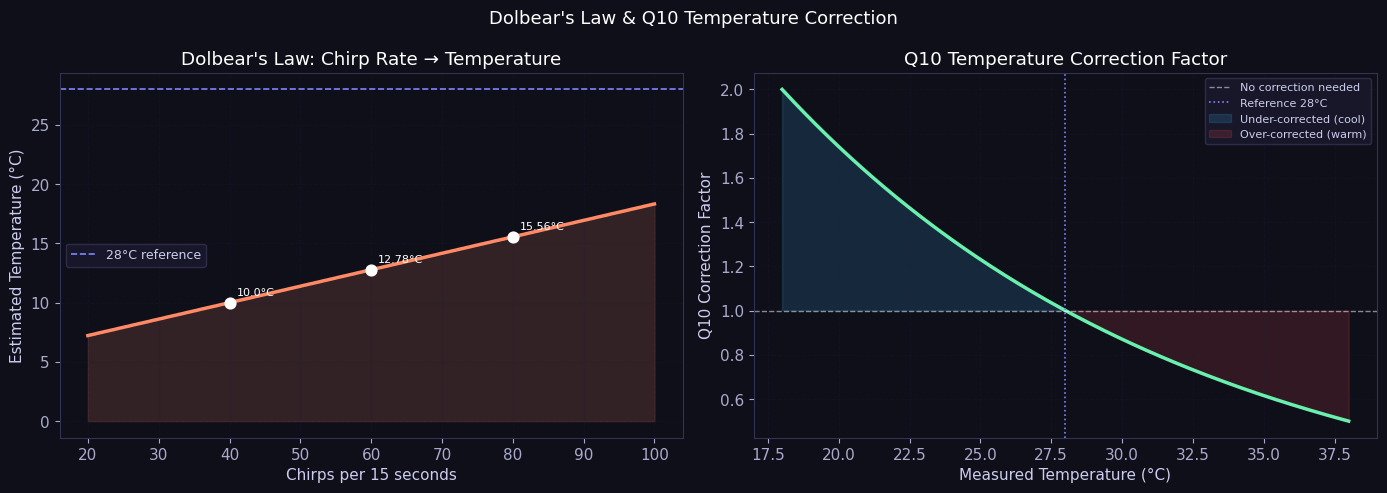

 Saved → results/04_dolbear_law.png


In [13]:
# ── Dolbear's Law visualization ───────────────────────────────────────────────
chirp_range = np.linspace(20, 100, 200)
temp_est    = [temperature_from_chirps(c) for c in chirp_range]

# Q10 correction factor across temperature range
temp_range = np.linspace(18, 38, 200)
q10_factors = [chirp_rate_correction_factor(t, reference_temp_c=28.0) for t in temp_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dolbear's Law & Q10 Temperature Correction", fontsize=13, color='white')

# Panel 1: chirps → temperature
ax = axes[0]
ax.plot(chirp_range, temp_est, color='#ff8a65', lw=2.5)
ax.axhline(28, color='#7c85ff', ls='--', lw=1.2, label='28°C reference')
ax.fill_between(chirp_range, temp_est, alpha=0.15, color='#ff8a65')
ax.set_xlabel('Chirps per 15 seconds')
ax.set_ylabel('Estimated Temperature (°C)')
ax.set_title("Dolbear's Law: Chirp Rate → Temperature", color='white')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
# Sample points
for chirps, label in [(40,'40 chirps'), (60,'60 chirps'), (80,'80 chirps')]:
    t = temperature_from_chirps(chirps)
    ax.scatter([chirps], [t], color='white', s=60, zorder=5)
    ax.annotate(f'{t}°C', (chirps, t), textcoords='offset points',
                xytext=(5, 5), fontsize=8, color='white')

# Panel 2: Q10 correction factor
ax2 = axes[1]
ax2.plot(temp_range, q10_factors, color='#69f0ae', lw=2.5)
ax2.axhline(1.0, color='white', ls='--', lw=1, alpha=0.5, label='No correction needed')
ax2.axvline(28,  color='#7c85ff', ls=':', lw=1.2, label='Reference 28°C')
ax2.fill_between(temp_range, q10_factors, 1, where=[q > 1 for q in q10_factors],
                 alpha=0.15, color='#40c4ff', label='Under-corrected (cool)')
ax2.fill_between(temp_range, q10_factors, 1, where=[q < 1 for q in q10_factors],
                 alpha=0.15, color='#ff5252', label='Over-corrected (warm)')
ax2.set_xlabel('Measured Temperature (°C)')
ax2.set_ylabel('Q10 Correction Factor')
ax2.set_title('Q10 Temperature Correction Factor', color='white')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig(RESULTS / '04_dolbear_law.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(' Saved → results/04_dolbear_law.png')

## 9️⃣ Per-Cluster Behavior Analysis (Static)

วิเคราะห์ว่าแต่ละ cluster ถ้าครอง soundscape 100% จะ trigger alert อะไร

In [14]:
# ── Run BehaviorMonitor on each cluster independently ─────────────────────────
per_cluster_results = []

for _, row in cluster_summary_valid.iterrows():
    cid = int(row['cluster'])
    # As if this cluster dominated 100% of the soundscape
    cluster_fracs = {c: 0.0 for c in all_cluster_ids}
    cluster_fracs[cid] = 1.0
    cluster_fracs[-1] = 0.0
    
    result = monitor.analyze(
        rms=row['rms_mean'],
        aci=row['aci_mean'],
        cluster_fractions=cluster_fracs,
        temperature_c=28.0,
    )
    
    per_cluster_results.append({
        'cluster':       cid,
        'song_type':     row['song_type'],
        'count':         row['count'],
        'rms_mean':      row['rms_mean'],
        'aci_mean':      row['aci_mean'],
        'rms_ratio':     result.mortality['rms_ratio'],
        'aci_ratio':     result.mortality['aci_ratio'],
        'hungry':        result.hunger['hungry'],
        'mortality_risk':result.mortality['mortality_risk'],
        'dom_species':   row['dom_species'],
        'dom_purity':    row['dom_purity'],
    })

pcr = pd.DataFrame(per_cluster_results).sort_values('cluster')

print(f'Clusters that trigger HUNGER alert   : {pcr[pcr["hungry"]]["cluster"].tolist()}')
print(f'Clusters that trigger MORTALITY alert: {pcr[pcr["mortality_risk"]]["cluster"].tolist()}')
print()
display_cols = ['cluster','song_type','rms_ratio','aci_ratio','hungry','mortality_risk','dom_species']
print(pcr[display_cols].to_string(index=False))

🚨 Critical alerts at 2026-05-28T22:15:34.449873: ['⚠️  HUNGER ALERT: Aggressive fraction 100.0% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T22:15:34.450685: ['⚠️  HUNGER ALERT: Aggressive fraction 100.0% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T22:15:34.451106: ['⚠️  HUNGER ALERT: Aggressive fraction 100.0% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T22:15:34.451422: ['⚠️  HUNGER ALERT: Aggressive fraction 100.0% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T22:15:34.451763: ['⚠️  HUNGER ALERT: Aggressive fraction 100.0% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T22:15:34.452100: ['⚠️  HUNGER ALERT: Aggressive fraction 100.0% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T22:15:34.452461: ['🚨 MORTALITY RISK: RMS ratio=0.11, ACI ratio=0.97']
🚨 Critical alerts at 2026-05-28T22:15:34.452727: ['⚠️  HUNGER ALERT: Aggressive fraction 100.0% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T22:15:34.453083: ['⚠️  HUNGER ALERT: Aggressive fraction 100.0% ≥ 35.0%']
🚨 Critical alerts at 2026-05-28T22:15:34.453537: [

Clusters that trigger HUNGER alert   : [0, 1, 2, 3, 4, 5, 9, 10, 17, 18]
Clusters that trigger MORTALITY alert: [8, 11, 15, 16, 20, 21, 26, 27, 28, 29, 31, 35]

 cluster        song_type  rms_ratio  aci_ratio  hungry  mortality_risk                 dom_species
       0  Aggressive Song     5.8513     0.9573    True           False          Oecanthuspellucens
       1  Aggressive Song     2.2486     1.0107    True           False          Oecanthuspellucens
       2  Aggressive Song     5.3834     1.1068    True           False           Grylluscampestris
       3  Aggressive Song     2.5978     0.9439    True           False          Oecanthuspellucens
       4  Aggressive Song     2.1656     0.9517    True           False          Oecanthuspellucens
       5  Aggressive Song     2.2767     0.9598    True           False          Oecanthuspellucens
       6 Quiet/Background     0.7716     0.9333   False           False          Nemobiussylvestris
       7     Calling Song     0.6771   

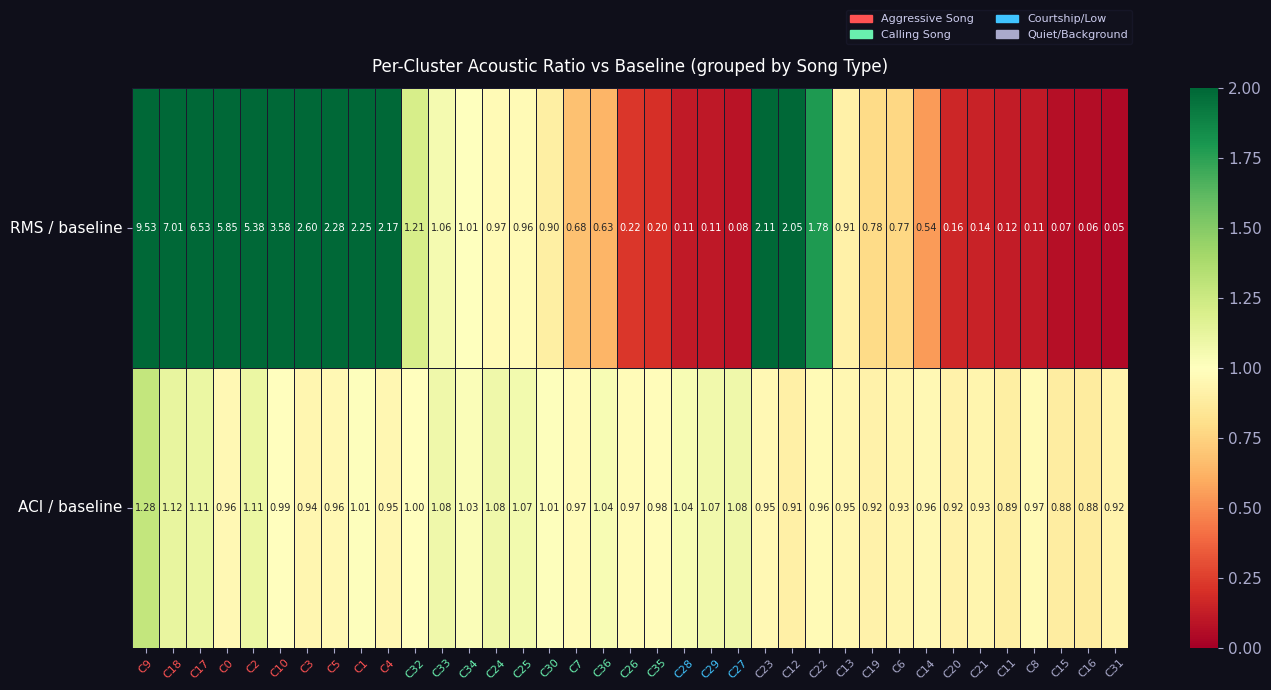

 Saved → results/04_cluster_heatmap.png


In [15]:
# ── Heatmap: cluster acoustic signature ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

type_order = ['Aggressive Song', 'Calling Song', 'Courtship/Low', 'Quiet/Background']
pcr_sorted = pd.concat([
    pcr[pcr['song_type'] == t].sort_values('rms_ratio', ascending=False)
    for t in type_order
])

heat_data = pcr_sorted[['rms_ratio', 'aci_ratio']].T
heat_data.columns = [f'C{int(c)}' for c in pcr_sorted['cluster']]

sns.heatmap(
    heat_data,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=0, vmax=2,
    linewidths=0.5, linecolor='#1a1a2e',
    ax=ax,
    annot_kws={'size': 7},
)

ax.set_title('Per-Cluster Acoustic Ratio vs Baseline (grouped by Song Type)',
             color='white', fontsize=12, pad=12)
ax.set_yticklabels(['RMS / baseline', 'ACI / baseline'], rotation=0, color='white')
ax.tick_params(axis='x', rotation=45, colors='#aaaacc', labelsize=8)

# Colour-code x-axis labels by song type
type_colors = {
    'Aggressive Song': '#ff5252',
    'Calling Song':    '#69f0ae',
    'Courtship/Low':   '#40c4ff',
    'Quiet/Background':'#aaaacc',
}
for tick, (_, row) in zip(ax.get_xticklabels(), pcr_sorted.iterrows()):
    tick.set_color(type_colors.get(row['song_type'], 'white'))

# Legend
legend_patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.01, 1.15),
          fontsize=8, framealpha=0.2, ncol=2)

plt.tight_layout()
fig.savefig(RESULTS / '04_cluster_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(' Saved → results/04_cluster_heatmap.png')

## 🔟 Export Results & Summary

In [16]:
# ── Export timeseries alerts CSV ──────────────────────────────────────────────
ts_export = ts_df[[
    'timestamp','temperature_c','rms','aci',
    'rms_ratio','aci_ratio','aggressive_frac',
    'hungry','mortality_risk','is_critical'
]].copy()
ts_export.to_csv(RESULTS / '04_behavior_timeseries.csv', index=False)

# ── Export cluster labels CSV ─────────────────────────────────────────────────
cluster_export = cluster_summary_valid[[
    'cluster','song_type','count','fraction',
    'rms_mean','aci_mean','dom_species','dom_purity'
]].copy()
cluster_export.to_csv(RESULTS / '04_cluster_labels.csv', index=False)

print(' Exported:')
print('   results/04_behavior_timeseries.csv')
print('   results/04_cluster_labels.csv')
print()

# ── Final Summary ─────────────────────────────────────────────────────────────
print('=' * 55)
print('  🦗 CRICKET PERCEPTION — BEHAVIOR ANALYSIS SUMMARY')
print('=' * 55)
print(f'  Dataset     : InsectSet32 ({df["species"].nunique()} species)')
print(f'  Segments    : {len(df):,} total, {(labels!=-1).sum()} clustered')
print(f'  Clusters    : {n_clusters} (HDBSCAN auto-detected)')
print()
print('  Song Type Distribution:')
for t, cnt in cluster_summary_valid['song_type'].value_counts().items():
    print(f'    {t:22s} : {cnt} clusters')
print()
print(f'  Baseline RMS : {RMS_BASELINE:.5f}')
print(f'  Baseline ACI : {ACI_BASELINE:.2f}')
print()
print('  24h Simulation Results:')
print(f'    Hunger alerts    : {ts_df["hungry"].sum()}/{N_WINDOWS} windows')
print(f'    Mortality alerts : {ts_df["mortality_risk"].sum()}/{N_WINDOWS} windows')
print()
print('  Output files (results/):')
for f in [
    '04_cluster_characterisation.png',
    '04_umap_song_types.png',
    '04_baseline_calibration.png',
    '04_behavior_dashboard.png',
    '04_dolbear_law.png',
    '04_cluster_heatmap.png',
    '04_behavior_timeseries.csv',
    '04_cluster_labels.csv',
]:
    print(f'    ✅ {f}')
print('=' * 55)

 Exported:
   results/04_behavior_timeseries.csv
   results/04_cluster_labels.csv

  🦗 CRICKET PERCEPTION — BEHAVIOR ANALYSIS SUMMARY
  Dataset     : InsectSet32 (9 species)
  Segments    : 759 total, 663 clustered
  Clusters    : 37 (HDBSCAN auto-detected)

  Song Type Distribution:
    Quiet/Background       : 14 clusters
    Aggressive Song        : 10 clusters
    Calling Song           : 10 clusters
    Courtship/Low          : 3 clusters

  Baseline RMS : 0.00848
  Baseline ACI : 531.53

  24h Simulation Results:
    Hunger alerts    : 8/48 windows
    Mortality alerts : 5/48 windows

  Output files (results/):
    ✅ 04_cluster_characterisation.png
    ✅ 04_umap_song_types.png
    ✅ 04_baseline_calibration.png
    ✅ 04_behavior_dashboard.png
    ✅ 04_dolbear_law.png
    ✅ 04_cluster_heatmap.png
    ✅ 04_behavior_timeseries.csv
    ✅ 04_cluster_labels.csv


---

## 📋 สรุป Pipeline ครบวงจร

```
Raw Audio (.wav)
    ↓  audio_utils.py  — load, segment 2.5s, denoise
Feature Matrix (N × 53)
    ↓  features.py     — MFCC·Spectral·Chroma·RMS·ACI
UMAP Embedding (N × 2)
    ↓  clustering.py   — UMAP + HDBSCAN
Cluster Labels (N,)
    ↓  behavior.py     — BehaviorMonitor
Farm Alerts  ⚠️🚨✅
```

### ขั้นตอนถัดไปสำหรับ Farm จริง

1. **Collect labeled baseline** — บันทึกเสียงฟาร์มที่สุขภาพดี 3-7 วัน → calibrate RMS/ACI baseline
2. **Manual cluster labeling** — ฟังตัวอย่างเสียงจากแต่ละ cluster แล้ว label เป็น Aggressive/Calling จริงๆ
3. **Real-time inference** — รัน pipeline ทุก 30 นาทีบน Raspberry Pi / edge device
4. **Alert integration** — ส่ง alert ผ่าน LINE Notify / MQTT / Dashboard